# Figure 4 Supplementary — plot-data-only cache

This notebook is reorganized so that only the final data needed to redraw the UMAP parameter-sensitivity figure are cached.

The cache stores only:

- `n_neighbors_list`
- `min_dist_list`
- `all_spikes_label`
- all 25 UMAP embeddings
- the 25 silhouette scores
- the shared global plotting bounds

It does **not** store the original raw `.mat` inputs inside the cache.

**Workflow**
- **First run only:** load the raw features/labels once, compute the 25 embeddings and scores, then save only the final plot data.
- **Later runs:** load the cache and redraw the 5×5 panel figure directly.


In [1]:
# ============================================================
# PLOT ONLY LOADER — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw-data loading
# No UMAP fitting
# No silhouette recomputation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

CACHE_FILE = "Figure4_Suppl_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    n_neighbors_list = cached["n_neighbors_list"]
    min_dist_list = cached["min_dist_list"]
    all_spikes_label = cached["all_spikes_label"]
    embeddings = cached["embeddings"]
    scores = cached["scores"]
    x_min_plot = float(cached["x_min_plot"])
    x_max_plot = float(cached["x_max_plot"])
    y_min_plot = float(cached["y_min_plot"])
    y_max_plot = float(cached["y_max_plot"])

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12
})

c_list = []
for spike in all_spikes_label:
    if spike == 0:
        c_list.append([0, 0, 0])
    else:
        c_list.append([1, 0, 0])

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no upstream computation is being rerun.")


Loaded: Figure4_Suppl_plot_inputs.npz
Plotting only — no upstream computation is being rerun.


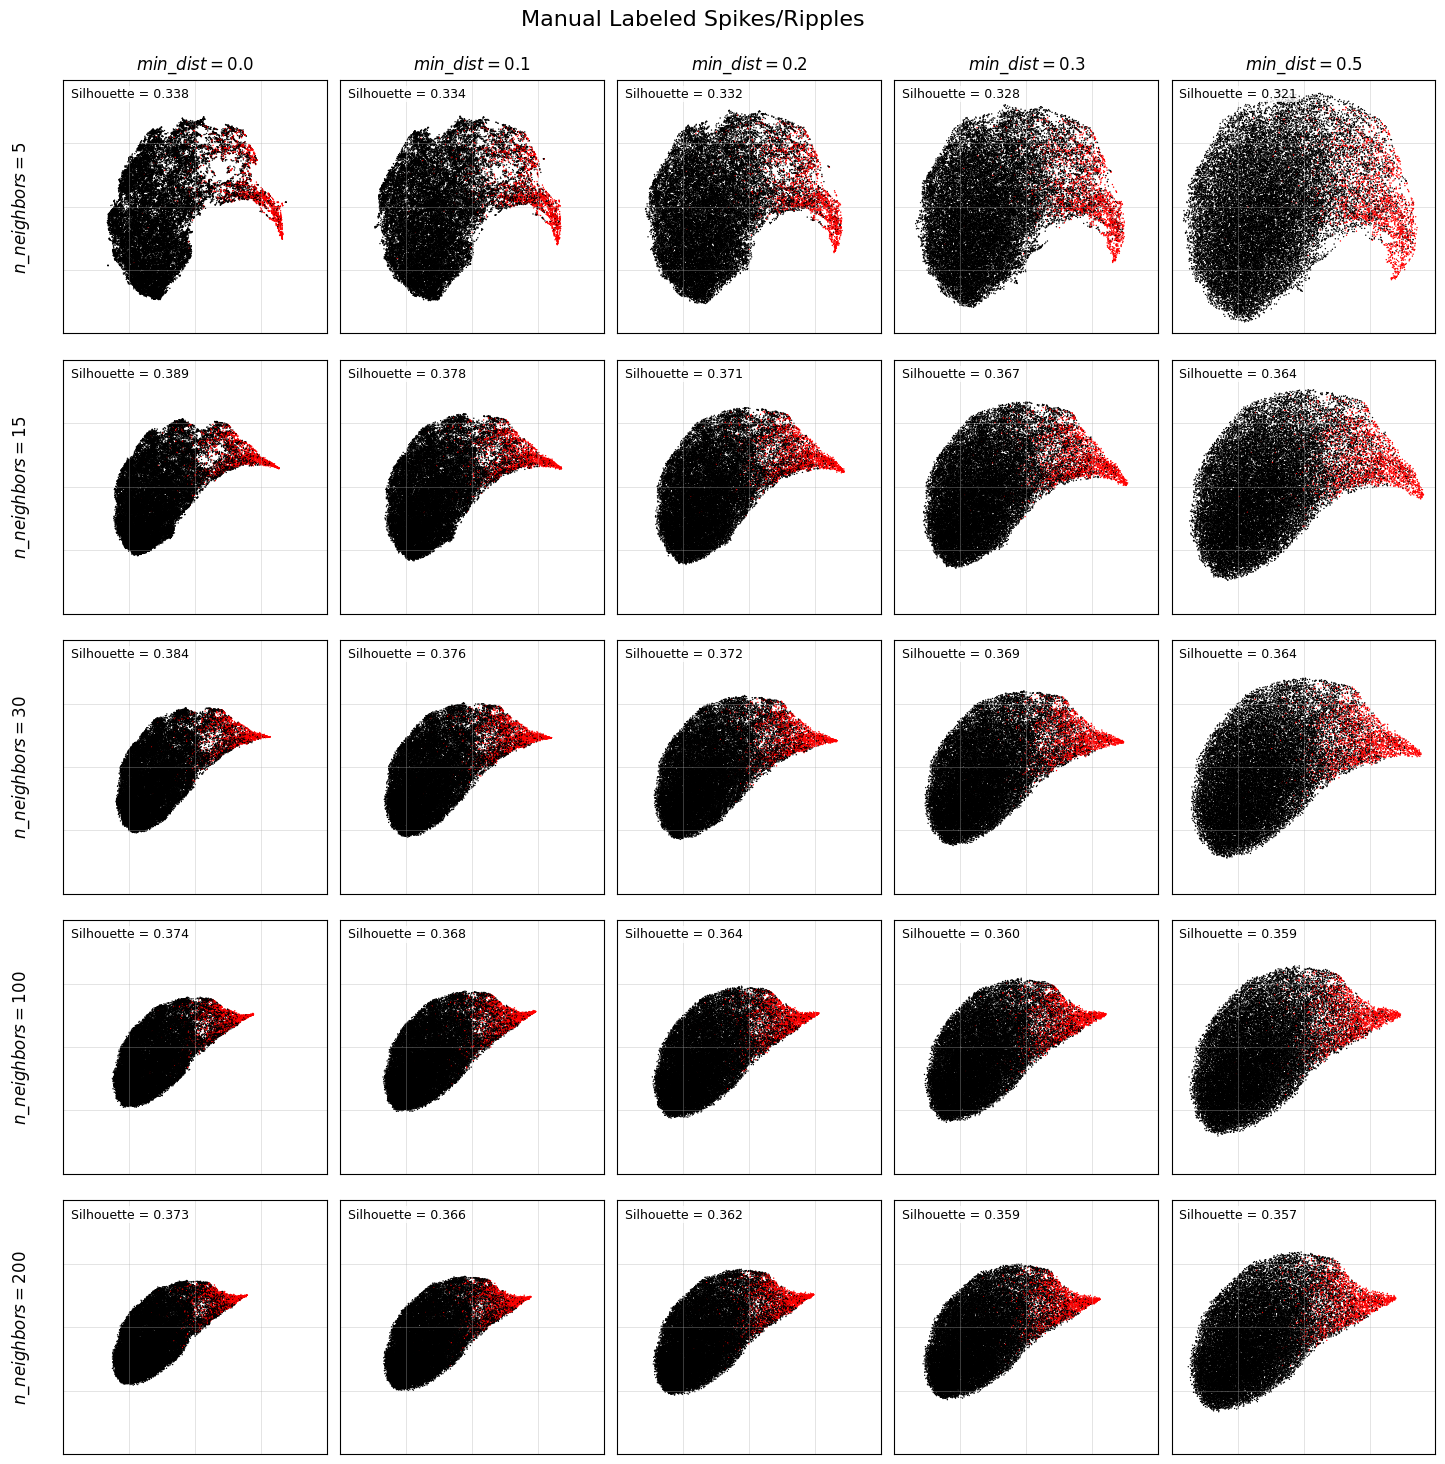

In [2]:
# ============================================================
# PLOT ONLY — UMAP PARAMETER SENSITIVITY 5×5 GRID
# ============================================================

fig, axes = plt.subplots(
    nrows=len(n_neighbors_list),
    ncols=len(min_dist_list),
    figsize=(15, 15)
)

for i, n_nei in enumerate(n_neighbors_list):
    for j, min_d in enumerate(min_dist_list):
        ax = axes[i, j]
        embedding = embeddings[i, j]
        actual_score = scores[i, j]

        ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=c_list,
            s=1,
            linewidths=0,
            rasterized=True
        )

        ax.set_xlim(x_min_plot, x_max_plot)
        ax.set_ylim(y_min_plot, y_max_plot)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xticks(np.linspace(x_min_plot, x_max_plot, 5))
        ax.set_yticks(np.linspace(y_min_plot, y_max_plot, 5))

        ax.tick_params(
            axis="both",
            which="both",
            length=0,
            labelbottom=False,
            labelleft=False
        )

        ax.grid(
            True,
            linestyle="-",
            linewidth=0.6,
            alpha=0.4
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

        if i == 0:
            ax.set_title(
                rf"$min\_dist = {float(min_d)}$",
                fontsize=12,
                pad=8
            )

        if j == 0:
            ax.text(
                -0.16,
                0.5,
                rf"$n\_neighbors = {int(n_nei)}$",
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=12
            )

        ax.text(
            0.03,
            0.97,
            f"Silhouette = {actual_score:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
                pad=1.2
            )
        )

fig.suptitle("Manual Labeled Spikes/Ripples", fontsize=16, y=0.985)

plt.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.02,
    top=0.94,
    wspace=0.05,
    hspace=0.08
)

# Optional:
# fig.savefig("UMAP_parameter_sensitivity_5x5_grid.png", dpi=600, bbox_inches="tight", pad_inches=0.03)
# fig.savefig("UMAP_parameter_sensitivity_5x5_grid.pdf", bbox_inches="tight", pad_inches=0.03)

plt.show()
plt.close(fig)
